<a href="https://colab.research.google.com/github/jorgecordovas2001-droid/potato-blight-forecasting/blob/main/Potatoes_Illnesses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn openpyxl xgboost imbalanced-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)

sns.set(style="whitegrid", font_scale=1.0)
np.random.seed(42)

In [ ]:
file_path = '/content/potato_disease_dataset.xlsx'  # Adjust the path if necessary
data = pd.read_excel(file_path)

print("Shape:", data.shape)
display(data.head())
print("Columnas:", data.columns.tolist())

Shape: (5000, 10)


,humidity,temperature,sun_hours,crop_age,isolation_index,precipitation,humidity_var,temp_var,infection_prob,label
0,74.967142,12.523549,5.188594,61.020583,0.501604,8.207232,13.389822,0.911631,0.395963,0
1,68.617357,12.849021,4.247632,61.493568,0.536838,14.488569,0.700920,-4.710511,0.264717,0
2,76.476885,16.910683,9.014275,78.871126,0.273544,5.111250,9.610189,0.642456,0.573352,1
3,85.230299,14.294198,5.824659,64.515169,0.325001,5.978363,5.298667,-8.741898,0.585862,1
4,67.658466,13.711945,5.789806,30.128316,0.052029,2.250706,-10.320254,-1.883660,0.090835,0


Columnas: ['humidity', 'temperature', 'sun_hours', 'crop_age', 'isolation_index', 'precipitation', 'humidity_var', 'temp_var', 'infection_prob', 'label']


In [ ]:
feature_cols = ['humidity','temperature','sun_hours','crop_age',
                'isolation_index','precipitation','humidity_var','temp_var']

X = data[feature_cols].values
y = data['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling for sensitive models (Logistic and MLP)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [ ]:
# Logistic Regression (baseline lineal)
log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_sc, y_train)
log_pred = log_model.predict(X_test_sc)
log_prob = log_model.predict_proba(X_test_sc)[:,1]

# Random Forest (ensamble interpretable)
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

# MLP (simple neural network)
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), alpha=1e-3, max_iter=1000, random_state=42)
mlp_model.fit(X_train_sc, y_train)
mlp_pred = mlp_model.predict(X_test_sc)
mlp_prob = mlp_model.predict_proba(X_test_sc)[:,1]

# XGBoost (modern boosting)
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=42, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

Balance de clases:
label
healthy     0.6716
infected    0.3284
Name: proportion, dtype: float64


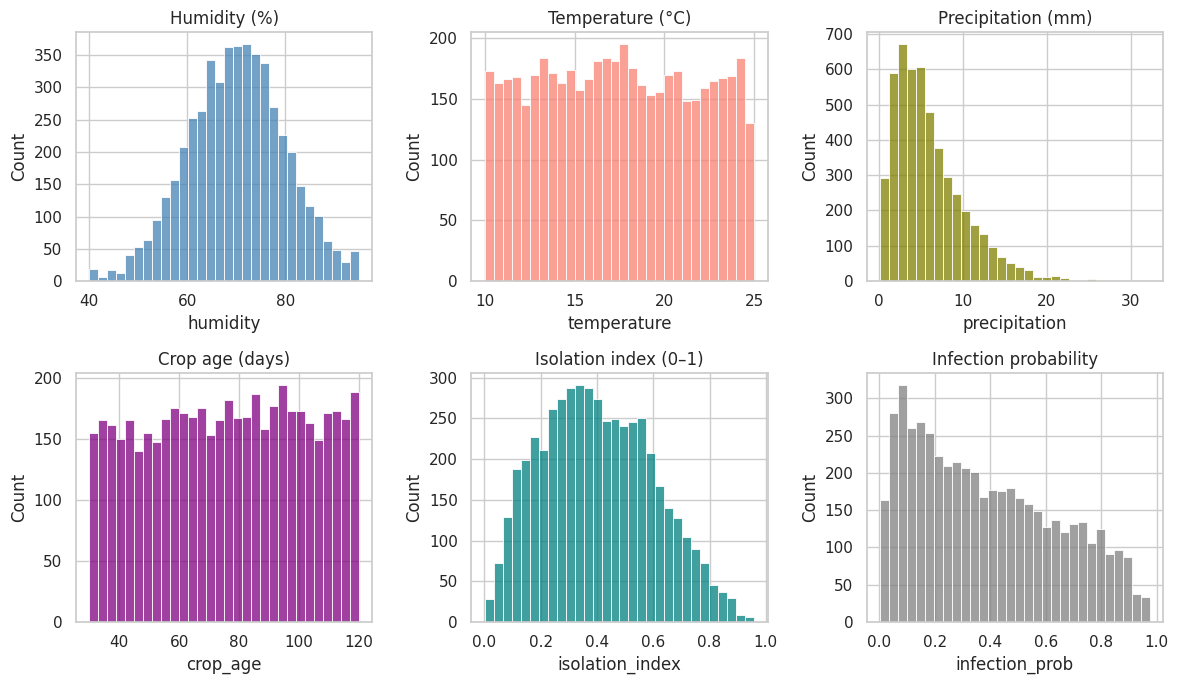

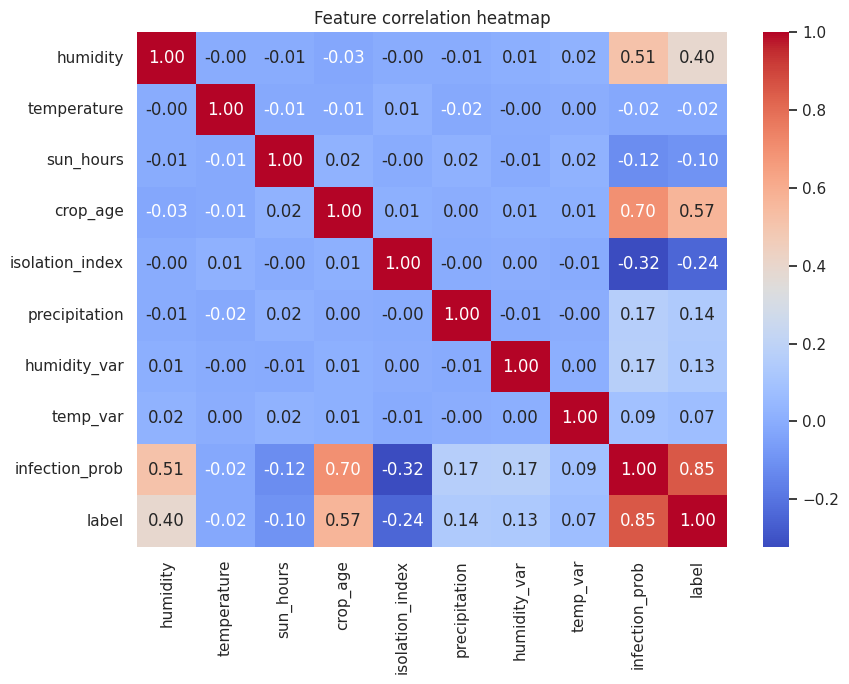

In [ ]:
# See class balance
print("Balance de clases:")
print(data['label'].value_counts(normalize=True).rename({0:'healthy', 1:'infected'}))

# Key variables histograms
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
sns.histplot(data['humidity'], bins=30, ax=axes[0,0], color='steelblue'); axes[0,0].set_title('Humidity (%)')
sns.histplot(data['temperature'], bins=30, ax=axes[0,1], color='salmon'); axes[0,1].set_title('Temperature (°C)')
sns.histplot(data['precipitation'], bins=30, ax=axes[0,2], color='olive'); axes[0,2].set_title('Precipitation (mm)')
sns.histplot(data['crop_age'], bins=30, ax=axes[1,0], color='purple'); axes[1,0].set_title('Crop age (days)')
sns.histplot(data['isolation_index'], bins=30, ax=axes[1,1], color='teal'); axes[1,1].set_title('Isolation index (0–1)')
sns.histplot(data['infection_prob'], bins=30, ax=axes[1,2], color='gray'); axes[1,2].set_title('Infection probability')
plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(9,7))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [ ]:
def metrics_summary(y_true, y_pred, y_prob, label):
    return {
        'model': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob)
    }

results = []
results.append(metrics_summary(y_test, log_pred, log_prob, 'Logistic'))
results.append(metrics_summary(y_test, rf_pred,  rf_prob,  'RandomForest'))
results.append(metrics_summary(y_test, mlp_pred, mlp_prob, 'MLP'))
results.append(metrics_summary(y_test, xgb_pred, xgb_prob, 'XGBoost'))

df_results = pd.DataFrame(results).round(3)
display(df_results)

,model,accuracy,precision,recall,f1,auc
0,Logistic,0.989,0.968,1.000,0.984,1.000
1,RandomForest,0.937,0.900,0.909,0.904,0.989
2,MLP,0.997,0.997,0.994,0.995,1.000
3,XGBoost,0.963,0.948,0.939,0.943,0.994


Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       672
           1       0.97      1.00      0.98       328

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000


Random Forest:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       672
           1       0.90      0.91      0.90       328

    accuracy                           0.94      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.94      0.94      0.94      1000


MLP:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       672
           1       1.00      0.99      1.00       328

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00     

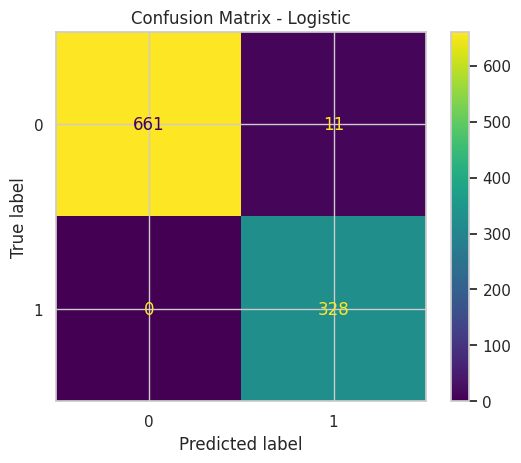

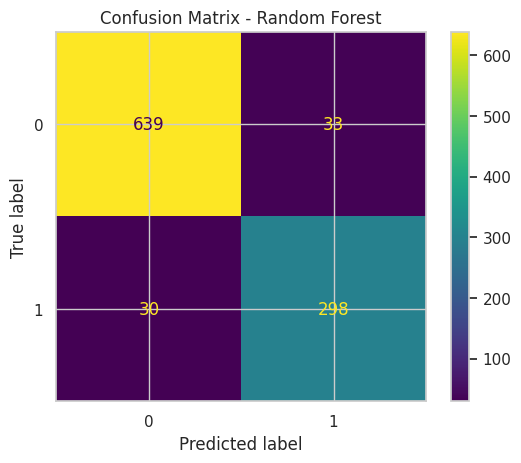

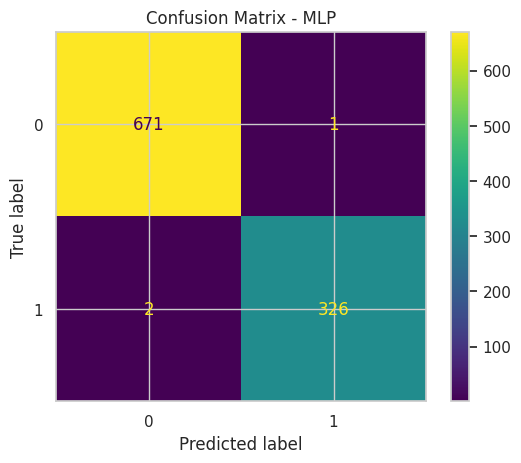

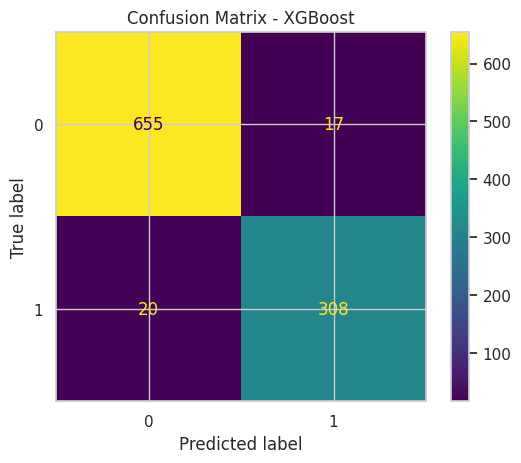

In [ ]:
print("Logistic Regression:\n", classification_report(y_test, log_pred))
print("\nRandom Forest:\n", classification_report(y_test, rf_pred))
print("\nMLP:\n", classification_report(y_test, mlp_pred))
print("\nXGBoost:\n", classification_report(y_test, xgb_pred))

ConfusionMatrixDisplay.from_estimator(log_model, X_test_sc, y_test)
plt.title("Confusion Matrix - Logistic")
plt.show()

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

ConfusionMatrixDisplay.from_estimator(mlp_model, X_test_sc, y_test)
plt.title("Confusion Matrix - MLP")
plt.show()

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test)
plt.title("Confusion Matrix - XGBoost")
plt.show()

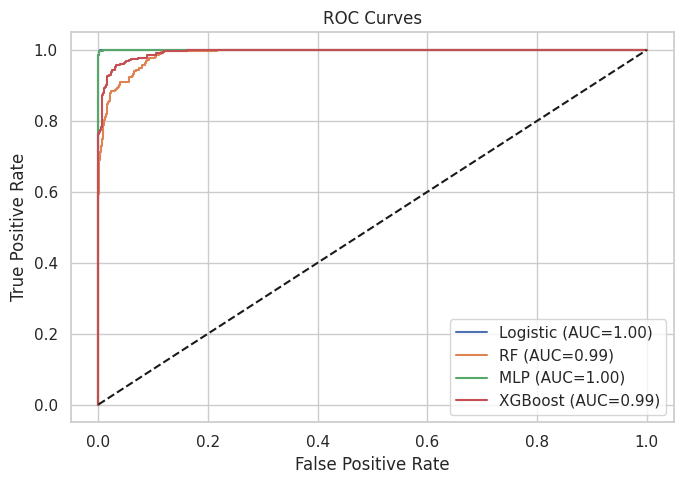

In [ ]:
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, rf_prob)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, mlp_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf,  tpr_rf)
auc_mlp = auc(fpr_mlp, tpr_mlp)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC={auc_log:.2f})')
plt.plot(fpr_rf,  tpr_rf,  label=f'RF (AUC={auc_rf:.2f})')
plt.plot(fpr_mlp, tpr_mlp, label=f'MLP (AUC={auc_mlp:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

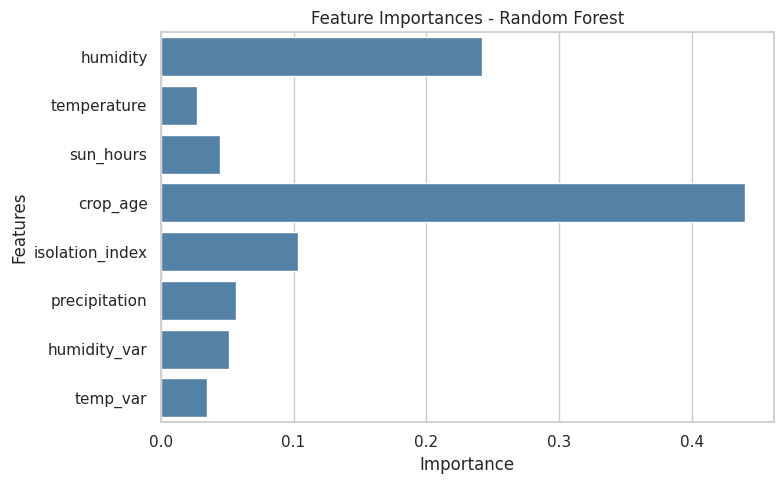

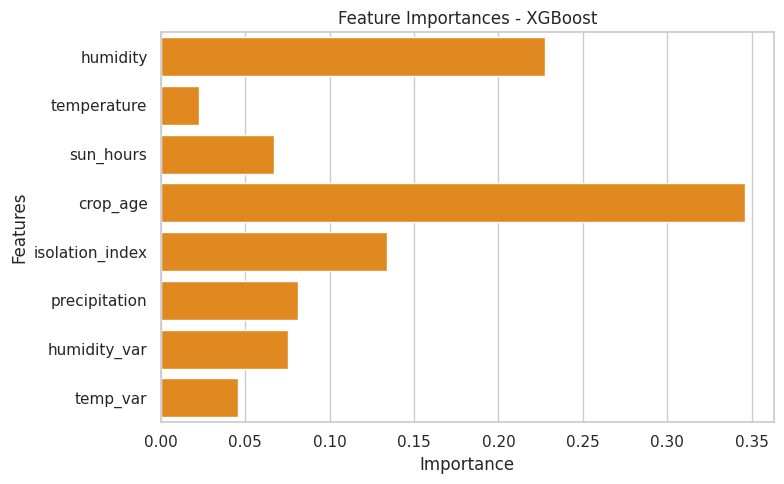

In [ ]:
# RF
rf_importances = rf_model.feature_importances_
plt.figure(figsize=(8,5))
sns.barplot(x=rf_importances, y=feature_cols, color='steelblue')
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# XGBoost
xgb_importances = xgb_model.feature_importances_
plt.figure(figsize=(8,5))
sns.barplot(x=xgb_importances, y=feature_cols, color='darkorange')
plt.title("Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

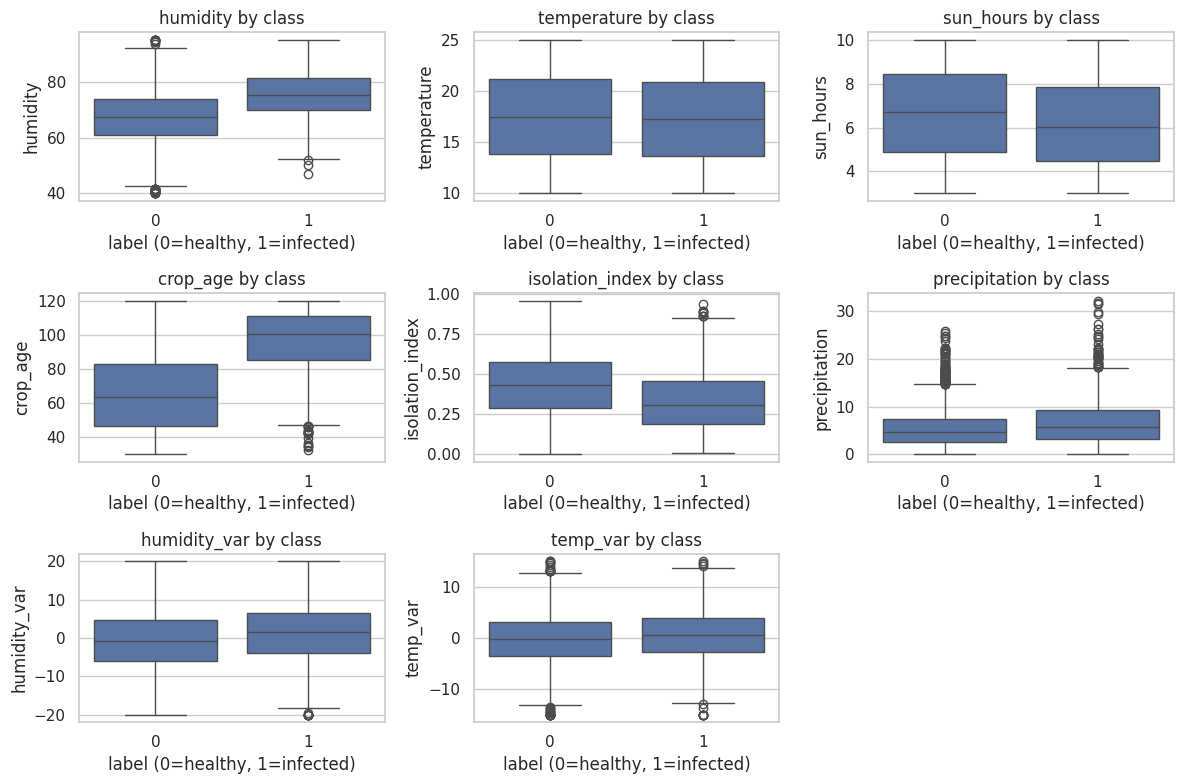

In [ ]:
plt.figure(figsize=(12,8))
for i, col in enumerate(feature_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(data=data, x='label', y=col)
    plt.title(f'{col} by class')
    plt.xlabel('label (0=healthy, 1=infected)')
    plt.tight_layout()
plt.show()

In [ ]:
def monte_carlo(model, X, y, n_runs=200, test_size=0.2, scaled=False):
    accs, recs, f1s, aucs = [], [], [], []
    sss = StratifiedShuffleSplit(n_splits=n_runs, test_size=test_size, random_state=42)
    for tr_idx, te_idx in sss.split(X, y):
        X_tr, X_te = X[tr_idx], X[te_idx]
        y_tr, y_te = y[tr_idx], y[te_idx]
        if scaled:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        y_prob = model.predict_proba(X_te)[:,1]
        accs.append(accuracy_score(y_te, y_pred))
        recs.append(recall_score(y_te, y_pred))
        f1s.append(f1_score(y_te, y_pred))
        aucs.append(roc_auc_score(y_te, y_prob))
    return {
        'acc_mean': np.mean(accs), 'acc_std': np.std(accs),
        'rec_mean': np.mean(recs), 'rec_std': np.std(recs),
        'f1_mean': np.mean(f1s),  'f1_std': np.std(f1s),
        'auc_mean': np.mean(aucs),'auc_std': np.std(aucs)
    }

mc_log = monte_carlo(LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X, y, scaled=True)
mc_rf  = monte_carlo(RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, class_weight='balanced'), X, y)
mc_mlp = monte_carlo(MLPClassifier(hidden_layer_sizes=(100,), alpha=1e-3, max_iter=1000, random_state=42), X, y, scaled=True)
mc_xgb = monte_carlo(XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0, random_state=42, eval_metric='logloss'), X, y)

pd.DataFrame([mc_log, mc_rf, mc_mlp, mc_xgb], index=['Logistic','RF','MLP','XGBoost']).round(3)

,acc_mean,acc_std,rec_mean,rec_std,f1_mean,f1_std,auc_mean,auc_std
Logistic,0.989,0.003,1.000,0.000,0.983,0.005,1.000,0.000
RF,0.939,0.007,0.891,0.017,0.905,0.011,0.987,0.002
MLP,0.994,0.002,0.990,0.006,0.990,0.004,1.000,0.000
XGBoost,0.961,0.006,0.928,0.015,0.940,0.010,0.995,0.001
